### Parte 1

In [33]:
import math
import numpy as np
import matplotlib.pyplot as plt
import logging
import tensorflow as tf
import tensorflow_datasets as tfds

In [34]:
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

In [35]:
dataset, metadata = tfds.load("mnist", as_supervised=True, with_info=True)
train_dataset, test_dataset = dataset["train"], dataset["test"]

In [36]:
class_names = [
    "Cero","Uno","Dos","Tres","Cuatro","Cinco","Seis","Siete","Ocho","Nueve"
]
num_train_examples = metadata.splits["train"].num_examples
num_test_examples = metadata.splits["test"].num_examples

In [37]:
def normalize(images, labels):
    images = tf.cast(images, tf.float32)
    images /= 255
    return images, labels

In [38]:
train_dataset = train_dataset.map(normalize)
test_dataset = test_dataset.map(normalize)

In [39]:
#Estructura de la red
model = tf.keras.Sequential([
tf.keras.layers.Flatten(input_shape=(28,28,1)), #Capa de entrada
tf.keras.layers.Dense(64, activation=tf.nn.relu), #Capas oculta
tf.keras.layers.Dense(64, activation=tf.nn.relu), #Capas oculta
tf.keras.layers.Dense(10, activation=tf.nn.softmax) #para clasificacion
])

In [40]:
#Función que compila el modelo
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

In [41]:
BATCHSIZE = 32
train_dataset = train_dataset.repeat().shuffle(num_train_examples).batch(BATCHSIZE)
test_dataset = test_dataset.batch(BATCHSIZE)

In [42]:
#Realizar el aprendizaje
model.fit(
train_dataset, epochs=5,
steps_per_epoch=math.ceil(num_train_examples/BATCHSIZE)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9202 - loss: 0.2729
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9648 - loss: 0.1190
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9726 - loss: 0.0901
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9785 - loss: 0.0701
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9829 - loss: 0.0553


In [43]:
#Evaluar nuestro modelo ya entrenado, contra el dataset de pruebas
test_loss, test_accuracy = model.evaluate(
test_dataset, steps=math.ceil(num_test_examples/32)
)
#Imprime los resultados de precisión
print("Resultado en las pruebas: ", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9741 - loss: 0.0923
Resultado en las pruebas:  0.9740999937057495


In [44]:
for test_images, test_labels in test_dataset.take(1):
    test_images = test_images.numpy()
    test_labels = test_labels.numpy()
    predictions = model.predict(test_images)

def plot_image(i, predictions_array, true_labels, images):
    predictions_array, true_label, img = predictions_array[i], true_labels[i], images[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img[...,0], cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'
    plt.xlabel("Prediccion: {}".format(class_names[predicted_label]), color=color)

def plot_value_array(i, predictions_array, true_label):
    predictions_array, true_label = predictions_array[i], true_label[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#888888")
    plt.ylim([0,1])
    predicted_label = np.argmax(predictions_array)
    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


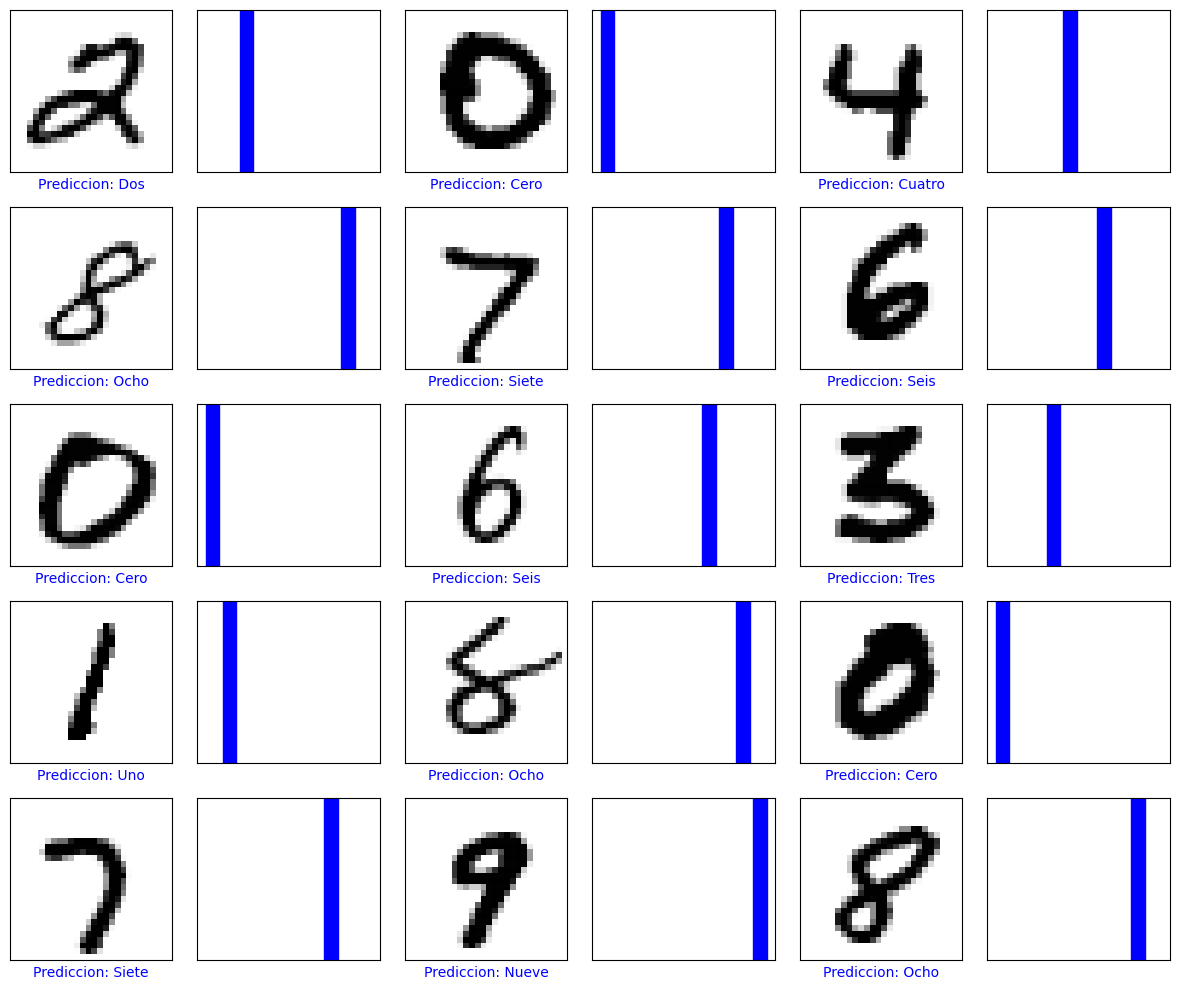

In [45]:
num_rows, num_cols = 5, 3
num_images = num_rows * num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))

for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions, test_labels, test_images)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictions, test_labels)

plt.tight_layout()
plt.show()

### Parte 2

In [46]:
from http.server import HTTPServer, BaseHTTPRequestHandler
from urllib import parse
import numpy as np
import threading

class SimpleHTTPRequestHandler(BaseHTTPRequestHandler):
    def do_POST(self):
        print("Peticion recibida")
        content_length = int(self.headers['Content-Length'])
        data = self.rfile.read(content_length)
        data = data.decode().replace('pixeles=', '')
        data = parse.unquote(data)

        arr = np.fromstring(data, np.float32, sep=",")
        arr = arr.reshape(28, 28)
        arr = np.array(arr)
        arr = arr.reshape(1, 28, 28, 1)

        prediction_values = model.predict(arr, batch_size=1)
        prediction = str(np.argmax(prediction_values))
        print("Prediccion final: " + prediction)

        self.send_response(200)
        self.send_header("Access-Control-Allow-Origin", "*")
        self.end_headers()
        self.wfile.write(prediction.encode())

    def log_message(self, *args):
        pass

servidor = HTTPServer(('', 8000), SimpleHTTPRequestHandler)
hilo = threading.Thread(target=servidor.serve_forever)
hilo.daemon = True
hilo.start()
print("Servidor listo en http://localhost:8000")

Servidor listo en http://localhost:8000


Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Prediccion final: 2
Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Prediccion final: 2
Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Prediccion final: 2
Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Prediccion final: 1
Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Prediccion final: 2
Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Prediccion final: 9
Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Prediccion final: 3
Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediccion final: 1
Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Prediccion final: 4
Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Prediccion final: 6
Peticion recibida
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Prediccion final: 2
